In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

,event,n,mean_ret_h1,median_ret_h1,hit_rate_h1,std_h1,mean_ret_h2,median_ret_h2,hit_rate_h2,std_h2,mean_ret_h3,median_ret_h3,hit_rate_h3,std_h3
29,long_posts,22,0.005407,0.001474,0.681818,0.011304,0.003833,0.005156,0.636364,0.015076,0.004656,0.005099,0.636364,0.017435
36,tariff_streak_3d,16,0.005173,0.005987,0.750000,0.006995,0.007623,0.004974,0.750000,0.009661,0.010186,0.008946,0.812500,0.011425
37,tariff_rising,20,0.003337,0.003151,0.550000,0.008134,0.006591,0.004088,0.750000,0.010516,0.009528,0.008161,0.750000,0.013327
26,sig_potus,120,0.002868,0.001387,0.608333,0.011968,0.003932,0.004232,0.708333,0.012471,0.004680,0.005663,0.650000,0.013295
7,deal_heavy,159,0.002041,0.001751,0.603774,0.012686,0.004049,0.002925,0.622642,0.018186,0.004607,0.003931,0.635220,0.022824
19,pre_tariff,65,0.001637,0.000899,0.538462,0.009805,0.001970,0.002358,0.646154,0.010909,0.000072,0.000593,0.523077,0.018405
32,tariff_only,76,0.001626,0.000168,0.500000,0.010871,0.003502,0.003074,0.592105,0.016472,0.002369,0.002172,0.565789,0.020927
34,has_chips,46,0.001477,0.001975,0.673913,0.008974,0.003740,0.005598,0.630435,0.013268,0.005376,0.007030,0.695652,0.020136
23,open_tariff,57,0.001122,0.001430,0.543860,0.010993,0.003890,0.003516,0.649123,0.018819,0.003260,0.003116,0.631579,0.021396
15,brag_heavy,32,0.001118,0.000017,0.500000,0.006970,-0.000489,-0.000143,0.468750,0.015282,-0.000548,0.000805,0.531250,0.016035


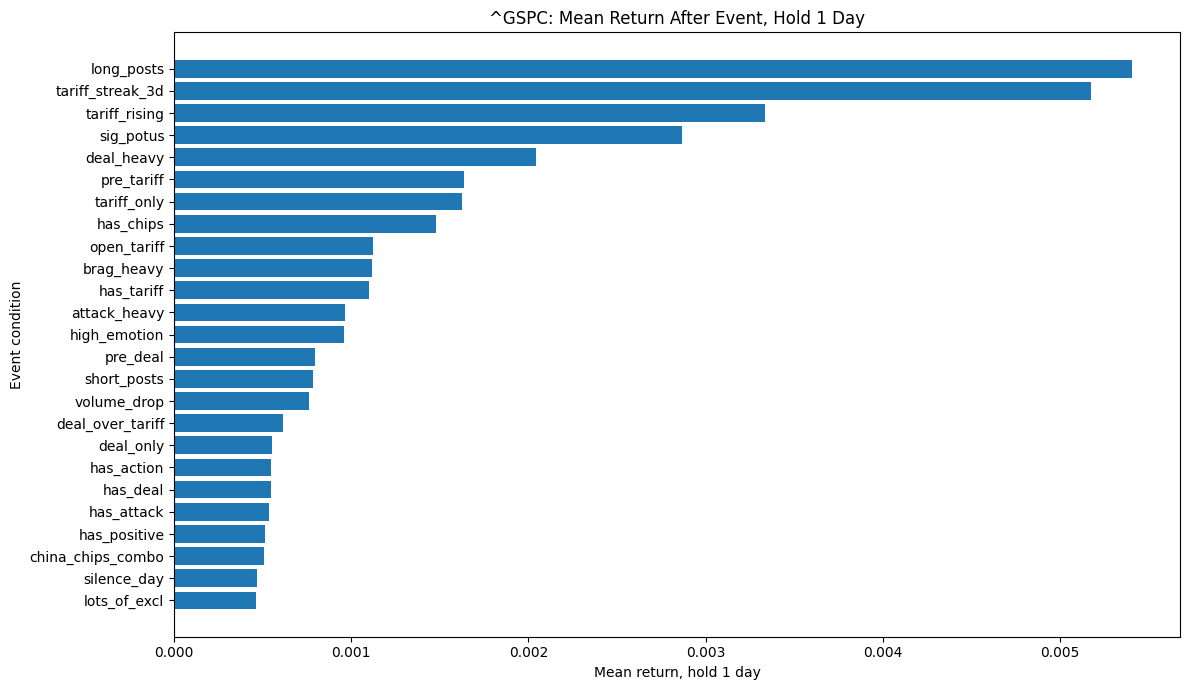

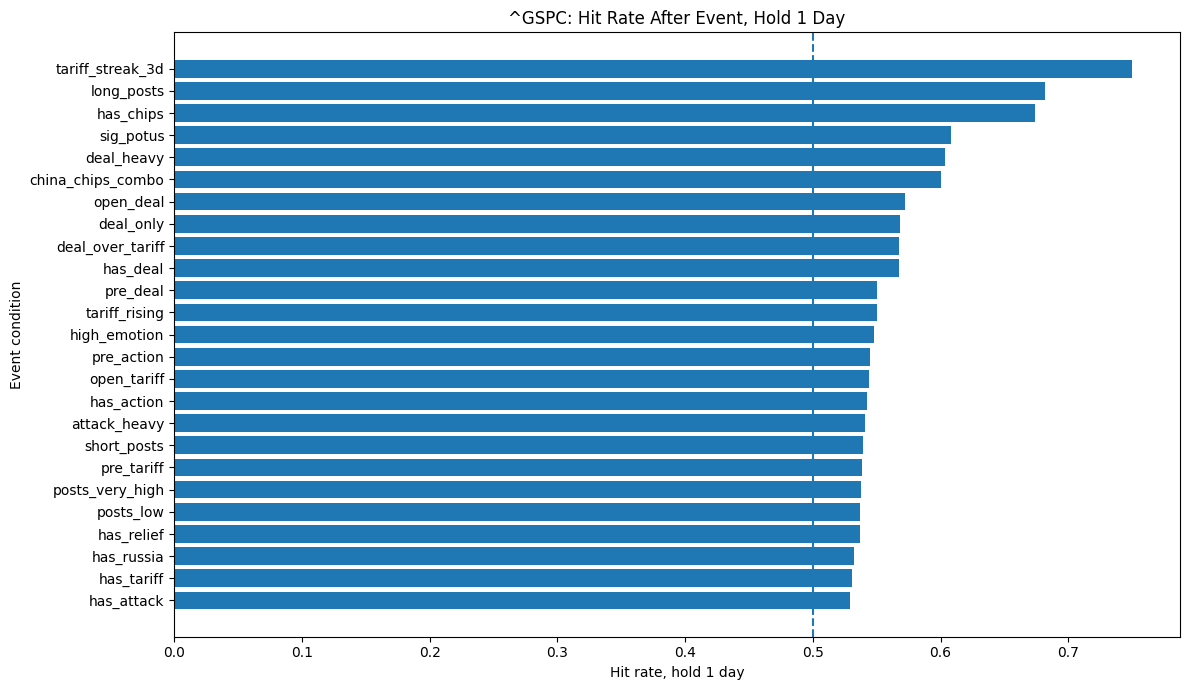

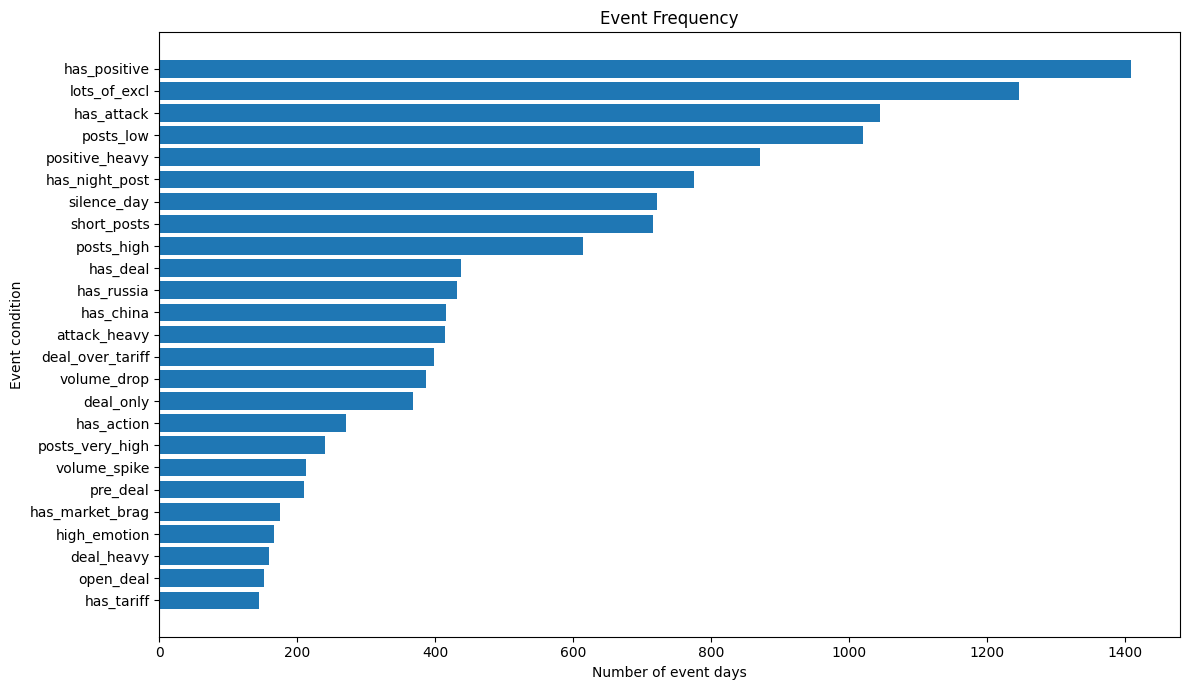

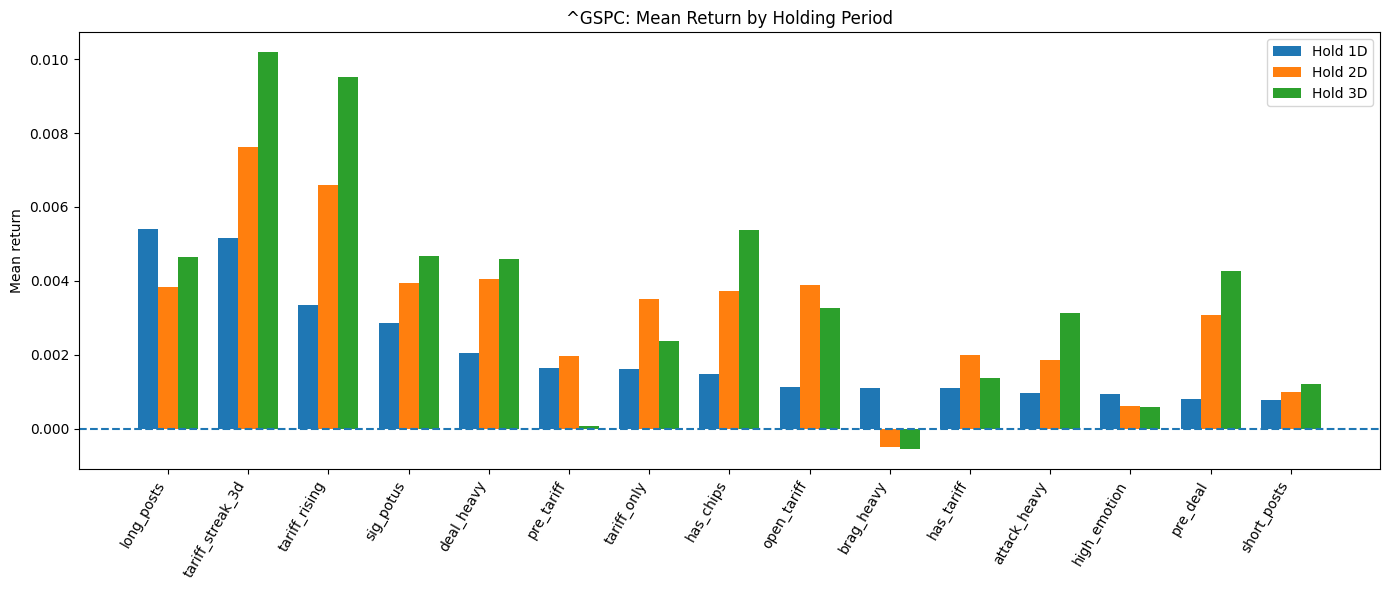

In [ ]:
# =====================================================
# 0. 參數
# =====================================================

TARGETS = [
    "0050.TW", "00632R.TW", "00679B.TW",
    "2303.TW", "2308.TW", "2317.TW", "2330.TW",
    "2376.TW", "2377.TW", "2382.TW", "2454.TW", "3711.TW"
]

PRICE_PATH = "taiwan_market_data/global_prices.csv"
EVENT_PATH = "./output/trump_daily_binary_event_features.csv"

HOLD_DAYS = [1, 2, 3]
MIN_EVENT_N = 10
TOP_N = 25

# =====================================================
# 1. 準備價格資料
# =====================================================

price_df = pd.read_csv(PRICE_PATH)
price_df["Date"] = pd.to_datetime(price_df["Date"])
price_df = price_df.sort_values("Date").set_index("Date")

available_targets = [t for t in TARGETS if t in price_df.columns]
missing_targets = [t for t in TARGETS if t not in price_df.columns]

print("Available targets:", available_targets)
print("Missing targets:", missing_targets)

# =====================================================
# 2. 準備事件資料
# =====================================================

event_df = pd.read_csv(EVENT_PATH)
event_df["trump_date"] = pd.to_datetime(event_df["trump_date"])
event_df = event_df.sort_values("trump_date").set_index("trump_date")

exclude_cols = {
    "post_count", "tariff_count", "deal_count", "relief_count",
    "china_count", "taiwan_count", "chips_count", "ai_count",
    "night_post_count", "pre_post_count", "open_post_count",
    "total_excl", "avg_post_len"
}

event_cols = [
    c for c in event_df.columns
    if c not in exclude_cols
    and event_df[c].dropna().isin([0, 1]).all()
]

print(f"Number of binary event features: {len(event_cols)}")

# =====================================================
# 3. 對單一 target 計算事件效果
# =====================================================

def evaluate_single_target(target):
    price = price_df[target].dropna()

    returns = pd.DataFrame(index=price.index)

    for hold in HOLD_DAYS:
        returns[f"ret_h{hold}"] = price.shift(-hold) / price - 1

    data = event_df[event_cols].join(returns, how="inner")

    results = []

    for event in event_cols:
        mask = data[event] == 1
        n = int(mask.sum())

        if n < MIN_EVENT_N:
            continue

        row = {
            "target": target,
            "event": event,
            "n": n,
        }

        for hold in HOLD_DAYS:
            r = data.loc[mask, f"ret_h{hold}"].dropna()

            row[f"mean_ret_h{hold}"] = r.mean()
            row[f"median_ret_h{hold}"] = r.median()
            row[f"hit_rate_h{hold}"] = (r > 0).mean()
            row[f"std_h{hold}"] = r.std()

        results.append(row)

    result_df = pd.DataFrame(results)

    if result_df.empty:
        return result_df

    result_df = result_df.sort_values("mean_ret_h1", ascending=False)
    return result_df

# =====================================================
# 4. 跑全部台股
# =====================================================

all_results = []

for target in available_targets:
    print(f"Evaluating {target}...")
    result = evaluate_single_target(target)
    all_results.append(result)

all_result_df = pd.concat(all_results, ignore_index=True)

display(all_result_df.head(50))

all_result_df.to_csv("./output/taiwan_event_return_analysis_all_targets.csv", index=False)

print("Saved: ./output/taiwan_event_return_analysis_all_targets.csv")

# =====================================================
# 5. 找出跨股票最有價值的事件
# =====================================================

summary = (
    all_result_df
    .groupby("event")
    .agg(
        avg_mean_ret_h1=("mean_ret_h1", "mean"),
        avg_mean_ret_h2=("mean_ret_h2", "mean"),
        avg_mean_ret_h3=("mean_ret_h3", "mean"),
        avg_hit_rate_h1=("hit_rate_h1", "mean"),
        avg_hit_rate_h2=("hit_rate_h2", "mean"),
        avg_hit_rate_h3=("hit_rate_h3", "mean"),
        avg_n=("n", "mean"),
        target_count=("target", "nunique"),
    )
    .reset_index()
)

summary["score_h1"] = (
    summary["avg_mean_ret_h1"] * 100
    + (summary["avg_hit_rate_h1"] - 0.5)
    + np.log1p(summary["avg_n"]) * 0.01
)

summary = summary.sort_values("score_h1", ascending=False)

display(summary.head(30))

summary.to_csv("./output/taiwan_event_return_analysis_summary.csv", index=False)

print("Saved: ./output/taiwan_event_return_analysis_summary.csv")

# =====================================================
# 6. 畫圖：跨股票平均報酬 Top events
# =====================================================

plot_df = summary.head(TOP_N).copy()

plt.figure(figsize=(12, 7))
plt.barh(plot_df["event"], plot_df["avg_mean_ret_h1"])
plt.axvline(0, linestyle="--")
plt.xlabel("Average mean return, hold 1 day")
plt.ylabel("Event condition")
plt.title("Taiwan Stocks: Average Mean Return After Trump Event, Hold 1 Day")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 7. 畫圖：跨股票平均勝率 Top events
# =====================================================

plot_df = summary.sort_values("avg_hit_rate_h1", ascending=False).head(TOP_N)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["event"], plot_df["avg_hit_rate_h1"])
plt.axvline(0.5, linestyle="--")
plt.xlabel("Average hit rate, hold 1 day")
plt.ylabel("Event condition")
plt.title("Taiwan Stocks: Average Hit Rate After Trump Event, Hold 1 Day")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 8. 畫圖：事件在多少檔股票上有資料
# =====================================================

plot_df = summary.sort_values("target_count", ascending=False).head(TOP_N)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["event"], plot_df["target_count"])
plt.xlabel("Number of target stocks")
plt.ylabel("Event condition")
plt.title("Event Coverage Across Taiwan Stocks")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 9. 單一股票畫圖函式
# =====================================================

def plot_target_result(target, metric="mean_ret_h1", top_n=25):
    df = all_result_df[all_result_df["target"] == target].copy()

    if df.empty:
        print(f"No result for {target}")
        return

    df = df.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(12, 7))
    plt.barh(df["event"], df[metric])

    if "hit_rate" in metric:
        plt.axvline(0.5, linestyle="--")
    else:
        plt.axvline(0, linestyle="--")

    plt.xlabel(metric)
    plt.ylabel("Event condition")
    plt.title(f"{target}: {metric} After Trump Event")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# 使用範例
plot_target_result("2330.TW", metric="mean_ret_h1")
plot_target_result("2330.TW", metric="hit_rate_h1")

# =====================================================
# 10. 找出最適合深度學習保留的事件
# =====================================================

valuable_events = summary[
    (summary["target_count"] >= 6) &
    (summary["avg_n"] >= 20) &
    (
        (summary["avg_hit_rate_h1"] > 0.55) |
        (summary["avg_hit_rate_h2"] > 0.55) |
        (summary["avg_hit_rate_h3"] > 0.55)
    ) &
    (
        (summary["avg_mean_ret_h1"] > 0.001) |
        (summary["avg_mean_ret_h2"] > 0.001) |
        (summary["avg_mean_ret_h3"] > 0.001)
    )
].copy()

valuable_events = valuable_events.sort_values("score_h1", ascending=False)

display(valuable_events)

valuable_events.to_csv("./output/valuable_trump_events_for_taiwan_stocks.csv", index=False)

print("Saved: ./output/valuable_trump_events_for_taiwan_stocks.csv")